## **Training a Vision Transformer on data generated on `sdg-engine`**
This short jupyter notebook tutorial is adapted from HF's more comprehensive [Fine-Tuning Object Detection Model on a Custom Dataset 🖼, Deployment in Spaces, and Gradio API Integration](https://huggingface.co/learn/cookbook/fine_tuning_detr_custom_dataset#fine-tuning-object-detection-model-on-a-custom-dataset--deployment-in-spaces-and-gradio-api-integration). 

This is however adapted for our use case, which is trainiing a Vision Transformer on synthetic data generated on Blender, and validate this against an open source real dataset to see how we perform.

TODO:
1. Rename `category` field to `categories` throughout the entire tutorial, this is what comes out from the synthetic dataset, and it just makes more sense...
2. Rename `bbox_id` to `bbox_ids` throughout the entire tutorial.

### **1. Loading our data from HuggingFace**
To start off, we'll need to load both our training data and our validation data from HuggingFace.

Luckily, I've already prepared both of these into `federicoarenas-ai/synthetic-bop-homebrew-scene-1-small`, `federicoarenas-ai/synthetic-bop-homebrew-scene1-large`, and finally the real validation-only dataset `federicoarenas-ai/real-homebrew-scene-1`(you can read more about where this dataset comes from in the card of the dataset here `<INSERT LINK>`).

In [ ]:
from datasets import load_dataset

# Load the synthetic dataset as your train_dataset
synthetic_dataset = load_dataset("federicoarenas-ai/synthetic-bop-homebrew-scene-3-medium", token="")
train_dataset = synthetic_dataset['train']

# Load the real dataset as your test_dataset
real_dataset = load_dataset("federicoarenas-ai/real-bop-homebrew-scene-3", token="")
test_dataset = real_dataset['validation']

### Visualizing our dataset
A great way of making sure our dataset matches the assumptions made by the process that will consume them for training is to visualize the bounding boxes under those assumptions.

Let's manually assign labels to every ID in the dataset.

In [ ]:
import numpy as np
from PIL import Image, ImageDraw

ID_TO_LABEL: dict[int, str] = {
    0: "Toy Cow",
    1: "Stapler",
    2: "Minion",
    3: "Butter", 
}
LABEL_TO_ID: dict[str, int] = {v: k for k, v in ID_TO_LABEL.items()}

We'll create some functionality to draw bounding boxes from our dataset.

In [ ]:
import matplotlib.pyplot as plt
from datasets import Dataset

def plot_image(dataset: Dataset, idx:int, transform=None):
    """Draw image in dataset after applying the input transform."""
    sample = dataset[idx]
    image = sample["image"]
    annotations = sample["objects"]

    # Apply transformation
    if transform:
        # Convert image to RGB and NumPy array
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        
        # Apply transformations
        augmented = transform(image=image, bboxes=annotations["bbox"], categories=annotations["categories"])
        image = augmented["image"]
        annotations["bbox"] = augmented["bboxes"]
        annotations["categories"] = augmented["categories"]
        
        # Convert image back to PIL Image
        image = Image.fromarray(image[:, :, ::-1])

    draw = ImageDraw.Draw(image)
    width, height = sample["width"], sample["height"]
    for i in range(len(annotations["bbox_ids"])):
        box = annotations["bbox"][i]
        x1, y1, w, h = tuple(box)
        x2, y2 = x1 + w, y1 + h

        # Normalize coordinates if necessary
        if max(box) <= 1.0:
            x1, y1 = int(x1 * width), int(y1 * height)
            x2, y2 = int(x2 * width), int(y2 * height)
        else:
            x1, y1 = int(x1), int(y1)
            x2, y2 = int(x2), int(y2)

        # Draw rectangles on top of the augmented images
        draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
        draw.text((x1, y1), ID_TO_LABEL[annotations["categories"][i]], fill="green")

    return image


def plot_images(dataset: Dataset, indices: list[int], transform=None):
    """
    Plot images and their annotations with optional augmentation.
    """
    num_rows = len(indices) // 3
    num_cols = 3
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

    for i, idx in enumerate(indices):
        row = i // num_cols
        col = i % num_cols

        # Draw augmented image
        image = plot_image(dataset, idx, transform=transform)

        # Display image on the corresponding subplot
        axes[row, col].imshow(image)
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

plot_images(train_dataset, range(9))
plot_images(test_dataset, range(9))

### **2. Data preparation**
Now we'll need to prepare the data using HF's `datasets` useful `map()` function, which can apply any given operation to each sample in our dataset.

Let's go through these operations.

### Operation 1: Filtering out invalid bounding boxes
To avoid problems during our downstream processes, and as a safety guard, we'll remove badly formatted bounding boxes from both the `train_dataset` and the `val_dataset`.

In [ ]:
def filter_invalid_bboxes(sample: dict):
    """Filter out samples with invalid bounding boxes."""
    # Go through each bounding box and filter out 
    # invalid bounding boxes
    valid_bboxes, valid_bbox_ids, valid_categories, valid_areas = [], [], [], []
    for i, bbox in enumerate(sample["objects"]["bbox"]):
        # Filter out bounding boxes with invalid coordinates
        x1, y1, w, h = bbox[:4]
        x2, y2 = x1 + w, y1 + h
        if x1 < x2 and y1 < y2:
            valid_bboxes.append(bbox)
            valid_bbox_ids.append(sample["objects"]["bbox_ids"][i])
            valid_categories.append(sample["objects"]["categories"][i])
            valid_areas.append(sample["objects"]["areas"][i])
        else:
            print(
                f"Image with invalid bbox: {sample['image_id']} Invalid bbox detected and discarded: {bbox} - category: {sample['objects']['categories'][i]}"
            )

    # Only keep valid bounding boxes for the given sample
    sample["objects"]["bbox"] = valid_bboxes
    sample["objects"]["bbox_ids"] = valid_bbox_ids
    sample["objects"]["categories"] = valid_categories
    sample["objects"]["areas"] = valid_areas

    return sample

# Perform filtering on both datasets
train_dataset = train_dataset.map(filter_invalid_bboxes)
test_dataset = test_dataset.map(filter_invalid_bboxes)

### Operations 2: Data Augmentations & tokenization
This operation is meatier than the last one, we'll prepare both of our datasets for training by (1) applying data augmentations to them, (2) formatting their annotations, and finally (3) tokenizing these so they are ready to be consumed by DETR.

#### Defining the Augmentations
Data augmentations will help our model better cope with random heterogeneity in the data, without us needing to generate it at the source. For this, we'll use the handy `albumentations` library, which simply lets us `A.Compose` multiple augmentations to apply to the data.

In [ ]:
import albumentations as A

# Our train augmentations should improve our classifiers robustness
train_transform = A.Compose(
    [
        A.LongestMaxSize(500),
        A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.5),
        A.Rotate(limit=10, p=0.5),
        A.RandomScale(scale_limit=0.2, p=0.5),
        A.GaussianBlur(p=0.5),
        A.GaussNoise(p=0.5),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["categories"]),
)

# Our validation augmentations should not tamper with 
# the final distribution we want to test on
test_transform = A.Compose(
    [
        A.LongestMaxSize(500),
        A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["categories"]),
)

Note that we apply different augmentations to `train` and `test`, because we'd like our train set to help train a robust clasifier, versus our val set to mimmic as closely as possible the data distribution we want our model to perform in.

#### Defining our tokenizer
Then, we'll initialize an `image_processor` from a generic checkpoint `facebook/detr-resnet-50-dc5`. Its function is encoding the input image into the right vector shape and distribution that will be needed before training -- departing from a pretrained DETR model.

In [ ]:
from transformers import AutoImageProcessor

checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

#### Defining our annotation format
Finally, we need to make sure our annotations abide by the format expected by our training and evaluation metrics, which in this case we define as COCO.

In [ ]:
def formatted_anns(
        image_id:int, 
        category:list[int], 
        bbox:list[float], 
        area:list[float]
    )-> list[dict]:
    """
    Format the annotation to a generic input format.
    
    This can thus be used by standard processes to calculate metrics
    on top of the annotations generated by our model, and the ground truth ones.

    Parameters
    ----------
    image_id: int
        unique identifier of the given sample.
    category: list[int]
        identifiers for all of the objects in the frame.
    bbox: list[float]
        COCO formatted bounding box locations for all objects
        in the frame. e.g. [[x1, y1, w, h], ...]
    area: list[float]
        areas of all bounding boxes for all 
        objects in the frame.
    
    Returns
    -------
    list[dict]
        COCO formatted annotations.
    """
    annotations = []
    for i in range(0, len(category)):
        annotations.append({
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        })

    return annotations

#### Putting it all together: applying the transformations
Let us define `transform_aug_ann` which, given a `sample` from our datasets (1) applies the augmentations, (2) formats the annotations, and finally (3) tokenizes the images with the `image_processor`.

In [ ]:

def transform_aug_ann(sample: dict, transform: A.BasicTransform):
    """Applies trainsformation to the provided sample."""
    image_ids = sample["image_id"]
    images, bboxes, categories, area = [], [], [], []
    for image, objects in zip(sample["image"], sample["objects"]):
        # Convert image to RGB and reverse the color channel to BGR
        image = np.array(image.convert("RGB"))[:, :, ::-1]

        # Apply the transformation
        out = transform(image=image, bboxes=objects["bbox"], categories=objects["categories"])
        
        # Collect data
        area.append(objects["areas"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["categories"])

    # Format the annotations as COCO-formatted annotations
    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, box_, area_)}
        for id_, cat_, box_, area_ in zip(image_ids, categories, bboxes, area)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

Let's use our friend `dataset.map()` to apply `transform_aug_ann` sample-wise.

In [ ]:
def transform_train(sample: dict):
    """Apply the `train_transform` to any given sample."""
    return transform_aug_ann(sample, transform=train_transform)


def transform_test(sample):
    """Apply the `test_transform` to any given sample."""
    return transform_aug_ann(sample, transform=test_transform)

    
# Apply the transformations
train_dataset_transformed = train_dataset.with_transform(transform_train)
test_dataset_transformed = test_dataset.with_transform(transform_test)

Let us also plot the first 9 images in our dataset after augmentations -- this will give us an idea of the kinds of perturbations done to the dataset!

In [ ]:
# Plot the augmented images
plot_images(train_dataset, range(9), transform=train_transform)

### **3. Training our Vision Transformer**
Just like the tutorial I linked above, we'll choose to use the `transformers.DetrForObjectDetection` architecture, and we'll initialize it exactly from the same checkpoint as we initialized the `image_processor`. Amongst many things, the DETR Architecture is a simpler pipeline than it's YOLO, RetinaNet precursors, and because we like simplicity (especially in object detection), we choose to use this.

#### Prepare training run

In [ ]:
from transformers import DetrForObjectDetection, TrainingArguments
import datetime

# Prepare training run hyperparameters
RUN_IDENTIFIER = f"vit-training-run-{datetime.datetime.now().strftime('%Y-%m-%d')}"
UNIQUE_RUN_IDENTIFIER = f"vit-training-run-{datetime.datetime.now().strftime('%Y-%m-%d-%H-%M-%S')}"

# Prepare model
model = DetrForObjectDetection.from_pretrained(
    checkpoint,
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
    ignore_mismatched_sizes=True,
)

# Define the training arguments
training_args = TrainingArguments(
    output_dir=UNIQUE_RUN_IDENTIFIER,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    max_steps=10000,
    save_steps=10,
    logging_steps=1,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    eval_steps=100,
    eval_strategy="steps",
    report_to="wandb",
    batch_eval_metrics=True,
)

#### Prepare monitoring using Weights & Biases

In [ ]:
import wandb

wandb.login()
wandb.init(
    id=UNIQUE_RUN_IDENTIFIER,
    project=RUN_IDENTIFIER,
    name=UNIQUE_RUN_IDENTIFIER,
    resume=True,
    config=training_args,
)

#### Prepare evaluation metrics

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.nn.functional import softmax
import torch
import warnings

def denormalize_boxes(
    boxes: torch.Tensor, 
    width: float, 
    height:float
    ):
    """Denormalize results multiplying by image width and height."""
    out = boxes.clone()
    out[:, [0, 2]] *= width  # x, w
    out[:, [1, 3]] *= height  # y, h
    return out

def build_target(label: dict) -> dict:
    """Build a target dict with absolute pixel boxes + class labels."""
    w, h = label["orig_size"]
    boxes = denormalize_boxes(label["boxes"], w, h)
    return {"boxes": boxes, "labels": label["class_labels"]}

def build_prediction(pred_box: torch.Tensor, score: torch.Tensor, w: int, h: int) -> dict:
    """Build a prediction dict from logits + normalized boxes."""
    # Drop background column, and collect probabilitites
    logits = score[:, :-1]  
    probs = softmax(logits, dim=-1)

    # predicted labels and their probs
    labels = probs.argmax(dim=-1)
    scores = probs.gather(1, labels.unsqueeze(1)).squeeze(1)

    boxes = denormalize_boxes(pred_box, w, h)
    return {"boxes": boxes, "scores": scores, "labels": labels}

In [ ]:
def process_batch(eval_pred) -> tuple[list[dict], list[dict]]:
    """Turn one batch from Trainer into TorchMetrics-friendly preds/targets."""
    (_, scores, pred_boxes, _, _), labels = eval_pred
    preds, targets = [], []

    for i, (label, pbox, sc) in enumerate(zip(labels, pred_boxes, scores)):
        try:
            w, h = label["orig_size"]
            targets.append(build_target(label))
            preds.append(build_prediction(pbox, sc, w, h))
        except Exception as e:
            warnings.warn(f"[process_batch] Skipping sample {i}: {e}")
            continue

    return preds, targets


def aggregate_and_compute(
    all_preds: list[dict], 
    all_targets: list[dict], 
    id_to_label: dict | None = None
) -> dict:
    """Compute mAP and flatten per-class metrics."""
    metric = MeanAveragePrecision(box_format="xywh", class_metrics=True)
    metric.update(preds=all_preds, target=all_targets)
    metrics = metric.compute()

    # Expand class-wise metrics
    classes = metrics.pop("classes")
    map_per_class = metrics.pop("map_per_class")
    mar_100_per_class = metrics.pop("mar_100_per_class")

    for cls_id, cls_map, cls_mar in zip(classes, map_per_class, mar_100_per_class):
        cls_name = id_to_label[cls_id.item()] if id_to_label else str(cls_id.item())
        metrics[f"map_{cls_name}"] = cls_map
        metrics[f"mar_100_{cls_name}"] = cls_mar

    return {k: round(v.item(), 4) for k, v in metrics.items()}

_batch_cache: list[dict] = []

def compute_metrics(eval_pred, compute_result: bool):
    """Stateless per-batch call OR final aggregation when compute_result=True."""
    global _batch_cache

    preds, targets = process_batch(eval_pred)

    if not compute_result:
        # accumulate batch outputs
        _batch_cache.append({"preds": preds, "targets": targets})
        return {}
    else:
        # aggregate everything
        all_preds, all_targets = [], []
        for batch in _batch_cache:
            all_preds.extend(batch["preds"])
            all_targets.extend(batch["targets"])

        metrics = aggregate_and_compute(all_preds, all_targets, ID_TO_LABEL)

        # clear cache for next eval
        _batch_cache = []
        return metrics

### Train the model

In [ ]:
from transformers import Trainer

def collate_fn(batch: list[torch.Tensor])-> torch.Tensor:
    """Collate function preparing a batch of samples."""
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]

    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels

    return batch

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset_transformed,
    eval_dataset=test_dataset_transformed,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

### **4. Visualizing some results**

In [ ]:
def plot_results(image, results, threshold=0.6):
    image = Image.fromarray(np.uint8(image))
    draw = ImageDraw.Draw(image)

    for result in results:
        score = result['score']
        label = result['label']
        box = list(result['box'].values())

        if score > threshold:
            x1, y1, x2, y2 = tuple(box)
            draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
            draw.text((x1 + 5, y1 - 10), label, fill="white")
            draw.text((x1 + 5, y1 + 10), f'{score:.2f}', fill='green' if score > 0.7 else 'red')

    return image

In [ ]:
from transformers import pipeline
object_detector = pipeline(task="object-detection", model=model, image_processor=image_processor)

image_idx: 35


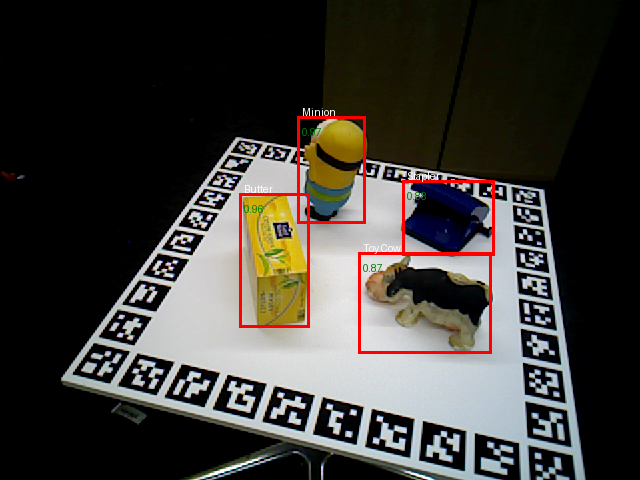

In [78]:
import random
image_idx = random.randint(0, len(test_dataset))

image = test_dataset[image_idx]['image']
results = object_detector(image)

print(f"image_idx: {image_idx}")
plot_results(image, results)